In [1]:
#3. Data Profiling

In [2]:
#Ingest all sheets with pandas.read_excel().

import pandas as pd
import numpy as np
import os
from datetime import datetime

# Load all CSVs
customers = pd.read_csv("Customers.csv")
models = pd.read_csv("MobileModels.csv")
shops = pd.read_csv("ShopLocations.csv")
sales = pd.read_csv("Sales.csv")
stocks = pd.read_csv("Stocks.csv")
offers = pd.read_csv("Offers.csv")

# Store in a dictionary for easy iteration
datasets = {
    "Customers": customers,
    "MobileModels": models,
    "ShopLocations": shops,
    "Sales": sales,
    "Stocks": stocks,
    "Offers": offers
}

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Check nulls, duplicates, and outliers in final_price, discount, loyalty_points

# Function to summarize missing values and duplicates
def profile_summary(df, name):
    summary = {
        "Dataset": name,
        "Rows": df.shape[0],
        "Columns": df.shape[1],
        "Missing Values": df.isnull().sum().sum(),
        "Duplicate Rows": df.duplicated().sum()
    }
    return summary

profile_results = pd.DataFrame([profile_summary(df, name) for name, df in datasets.items()])
print("DATA PROFILING SUMMARY:")
display(profile_results)

# Detailed missing values per column
for name, df in datasets.items():
    print(f"\n{name} - Missing Values per Column:")
    print(df.isnull().sum())

DATA PROFILING SUMMARY:


,Dataset,Rows,Columns,Missing Values,Duplicate Rows
0,Customers,6000,6,1149,0
1,MobileModels,200,6,0,0
2,ShopLocations,100,4,0,0
3,Sales,40000,10,3964,0
4,Stocks,8000,5,414,0
5,Offers,500,7,0,0



Customers - Missing Values per Column:
customer_id         0
full_name           0
email             311
phone             234
city                0
loyalty_points    604
dtype: int64

MobileModels - Missing Values per Column:
model_id      0
brand         0
model_name    0
ram_gb        0
storage_gb    0
price         0
dtype: int64

ShopLocations - Missing Values per Column:
shop_id         0
location        0
manager_name    0
rating          0
dtype: int64

Sales - Missing Values per Column:
sale_id            0
customer_id        0
model_id           0
shop_id            0
sale_date          0
quantity           0
discount        1993
final_price     1971
payment_mode       0
status             0
dtype: int64

Stocks - Missing Values per Column:
stock_id             0
shop_id              0
model_id             0
available_units    414
last_updated         0
dtype: int64

Offers - Missing Values per Column:
offer_id            0
model_id            0
shop_id             0
discoun

In [5]:
def detect_outliers(df, column):
    if column in df.columns:
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outliers = df[(df[column] < lower) | (df[column] > upper)]
        print(f"{column}: {len(outliers)} outliers detected.")
        return outliers
    else:
        print(f"{column} not found in dataset.")
        return pd.DataFrame()

# Check in Sales and Customers
outliers_final_price = detect_outliers(sales, "final_price")
outliers_discount = detect_outliers(sales, "discount")
outliers_loyalty = detect_outliers(customers, "loyalty_points")

final_price: 260 outliers detected.
discount: 0 outliers detected.
loyalty_points: 175 outliers detected.


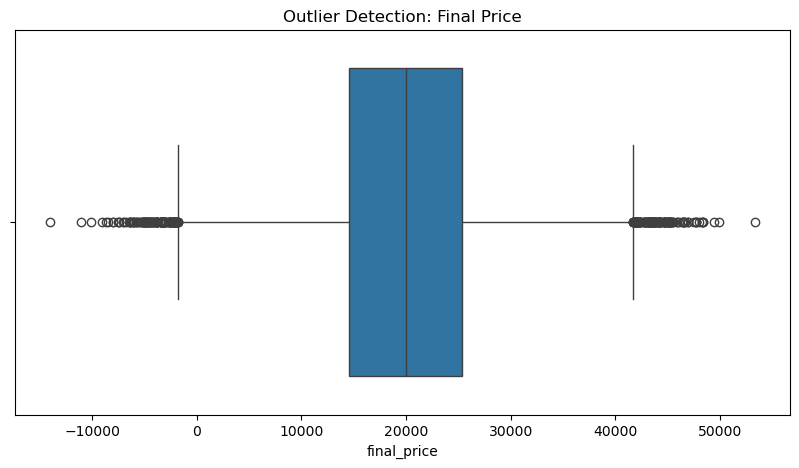

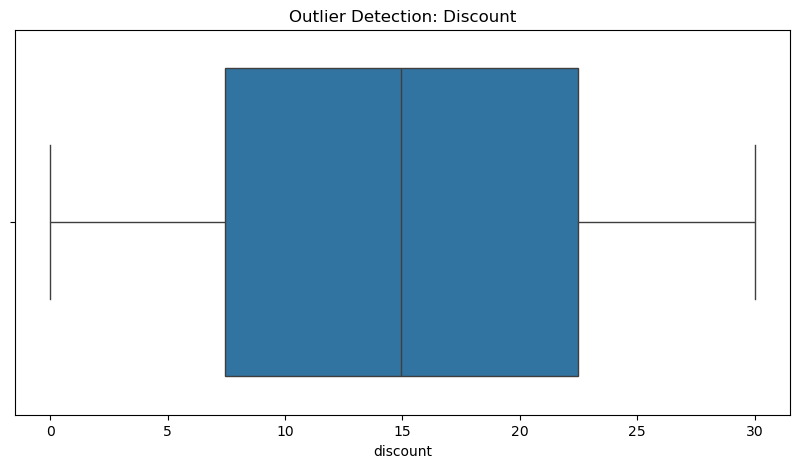

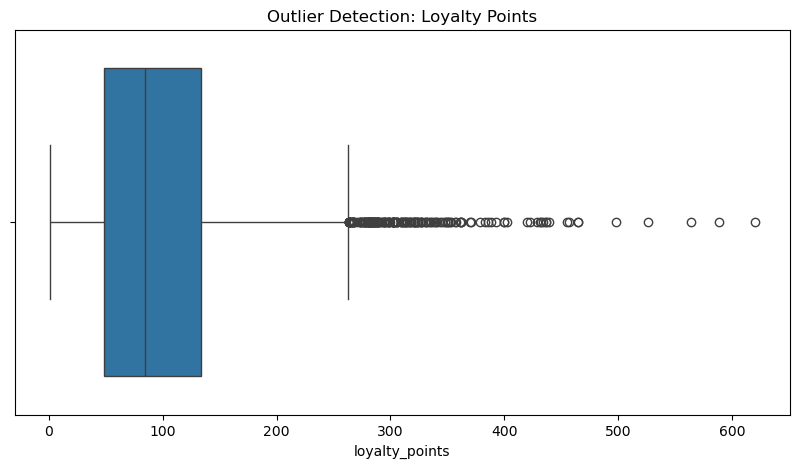

In [6]:
plt.figure(figsize=(10,5))
sns.boxplot(x=sales["final_price"])
plt.title("Outlier Detection: Final Price")
plt.show()

plt.figure(figsize=(10,5))
sns.boxplot(x=sales["discount"])
plt.title("Outlier Detection: Discount")
plt.show()

plt.figure(figsize=(10,5))
sns.boxplot(x=customers["loyalty_points"])
plt.title("Outlier Detection: Loyalty Points")
plt.show()

In [7]:
# Detect city spelling variants (e.g., Kolkatta → Kolkata, Hydrabad → Hyderabad).

# Check all unique city names
unique_cities = customers["city"].dropna().unique()
print("Unique City Names Before Cleaning:")
print(unique_cities)

# Create a mapping dictionary for corrections
city_corrections = {
    "Kolkatta": "Kolkata",
    "Hydrabad": "Hyderabad",
    "Bombay": "Mumbai",
    "Delhii": "Delhi",
    "Bengluru": "Bangalore",
    "Suratt" : "Surat",
    "Ahmedbad" : "Ahmedabad"
}

# Apply corrections
customers["city"] = customers["city"].replace(city_corrections)

print("\nUnique City Names After Cleaning:")
print(customers["city"].unique())

Unique City Names Before Cleaning:
['Suratt' 'Delhi' 'Ahmedbad' 'Bangalore' 'Jaipur' 'Chennai' 'Mumbai'
 'Pune' 'Hydrabad' 'Kolkatta']

Unique City Names After Cleaning:
['Surat' 'Delhi' 'Ahmedabad' 'Bangalore' 'Jaipur' 'Chennai' 'Mumbai'
 'Pune' 'Hyderabad' 'Kolkata']


In [8]:
# Validate join keys across Customers, Models, Shops, Sales, and Stocks.

# Check for orphaned records
invalid_customers = ~sales["customer_id"].isin(customers["customer_id"])
invalid_models = ~sales["model_id"].isin(models["model_id"])
invalid_shops = ~sales["shop_id"].isin(shops["shop_id"])

print("Invalid Foreign Key Counts:")
print("Sales without valid customer_id:", invalid_customers.sum())
print("Sales without valid model_id:", invalid_models.sum())
print("Sales without valid shop_id:", invalid_shops.sum())

# Optional: Remove orphan records
sales = sales[~invalid_customers & ~invalid_models & ~invalid_shops]

Invalid Foreign Key Counts:
Sales without valid customer_id: 0
Sales without valid model_id: 0
Sales without valid shop_id: 0


In [9]:
# Spot invalid statuses and payment modes.

# Check unique status values
print("Unique Sale Status Values:")
print(sales["status"].unique())

# Define valid statuses and payment modes
valid_statuses = ["Completed", "Cancelled", "Pending", "Returned"]
valid_payments = ["Cash", "Card", "UPI", "Wallet"]

# Detect invalid ones
invalid_statuses = sales[~sales["status"].isin(valid_statuses)]
invalid_payments = sales[~sales["payment_mode"].isin(valid_payments)]

print("\nInvalid Status Rows:", len(invalid_statuses))
print("Invalid Payment Mode Rows:", len(invalid_payments))

# Optional: Clean invalids
sales.loc[~sales["status"].isin(valid_statuses), "status"] = "Unknown"
sales.loc[~sales["payment_mode"].isin(valid_payments), "payment_mode"] = "Unknown"

Unique Sale Status Values:
['Completed' 'Pending' 'Cancelled']

Invalid Status Rows: 0
Invalid Payment Mode Rows: 19814


In [10]:
#Summary of profile findings
print("\n--- PROFILING SUMMARY ---")
print(f"Outliers in final_price: {len(outliers_final_price)}")
print(f"Outliers in discount: {len(outliers_discount)}")
print(f"Outliers in loyalty_points: {len(outliers_loyalty)}")
print(f"Invalid city spellings corrected: {len(city_corrections)}")
print(f"Orphan sales removed: {(invalid_customers.sum() + invalid_models.sum() + invalid_shops.sum())}")
print(f"Invalid statuses corrected: {len(invalid_statuses)}")
print(f"Invalid payment modes corrected: {len(invalid_payments)}")


--- PROFILING SUMMARY ---
Outliers in final_price: 260
Outliers in discount: 0
Outliers in loyalty_points: 175
Invalid city spellings corrected: 7
Orphan sales removed: 0
Invalid statuses corrected: 0
Invalid payment modes corrected: 19814


In [11]:
# --- FIX CITY SPELLINGS CLEANLY AND SAFELY ---

import pandas as pd

# Load your customers file
customers = pd.read_csv("customers.csv")

# 1) Convert all city names to consistent format
customers["city"] = customers["city"].str.strip().str.title()

# 2) Dictionary of wrong → correct spellings
city_corrections = {
    "Kolkatta": "Kolkata",
    "Kolkotta": "Kolkata",
    "Hydrabad": "Hyderabad",
    "Hydrebad": "Hyderabad",
    "Bombay": "Mumbai",
    "Delhii": "Delhi",
    "Bengluru": "Bangalore",
    "Benagluru": "Bangalore",
    "Suratt": "Surat",
    "Ahmedbad": "Ahmedabad",
    "Ahemdabad": "Ahmedabad"
}

# 3) Apply corrections
customers["city"] = customers["city"].replace(city_corrections)

# 4) Show BEFORE → AFTER changes
print("\nCorrected City Names:")
print(customers["city"].value_counts())

# 5) Save cleaned file
customers.to_csv("customers_cleaned.csv", index=False)

print("\nCity cleaning completed and saved as customers_cleaned.csv.")


Corrected City Names:
city
Jaipur       643
Delhi        623
Mumbai       617
Ahmedabad    615
Pune         603
Bangalore    599
Hyderabad    595
Kolkata      590
Chennai      564
Surat        551
Name: count, dtype: int64

City cleaning completed and saved as customers_cleaned.csv.


In [12]:
import pandas as pd

# Load your customers file
customers = pd.read_csv("customers.csv")

# 1) Standardize formatting
customers["city"] = customers["city"].astype(str).str.strip().str.title()

# 2) Dictionary of wrong → correct spellings
city_corrections = {
    "Kolkatta": "Kolkata",
    "Kolkotta": "Kolkata",
    "Hydrabad": "Hyderabad",
    "Hydrebad": "Hyderabad",
    "Bombay": "Mumbai",
    "Delhii": "Delhi",
    "Bengluru": "Bangalore",
    "Benagluru": "Bangalore",
    "Suratt": "Surat",
    "Ahmedbad": "Ahmedabad",
    "Ahemdabad": "Ahmedabad"
}

# 3) Apply corrections
customers["city"] = customers["city"].replace(city_corrections)

# 4) Print corrected list
print("\nCorrected City Names:")
print(customers["city"].value_counts())

# 5) OVERWRITE customers.csv with cleaned data
customers.to_csv("customers.csv", index=False)

print("\nCity cleaning completed and saved to customers.csv ✔")


Corrected City Names:
city
Jaipur       643
Delhi        623
Mumbai       617
Ahmedabad    615
Pune         603
Bangalore    599
Hyderabad    595
Kolkata      590
Chennai      564
Surat        551
Name: count, dtype: int64

City cleaning completed and saved to customers.csv ✔
